<a href="https://colab.research.google.com/github/OJB-Quantum/Cool-Mesh-Files/blob/main/Google%20Colab%20Notebooks/Two_Bar_Magnets_Solved_with_Elmer_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

#### Control Knobs

| Group | Knob | Default | Units | Meaning |
| :--- | :--- | ---: | :--- | :--- |
| Geometry | `Lm` | 30.0 | mm | Magnet length along x |
| Geometry | `Wm` | 10.0 | mm | Magnet width along y |
| Geometry | `Hm` | 6.0 | mm | Magnet height along z |
| Geometry | `gap` | 5.0 | mm | Gap between magnets along x |
| Geometry | `pad_x_mult` | 2.0 | – | Air padding in x = pad_x_mult * Lm per side |
| Geometry | `pad_y_mult` | 3.0 | – | Air padding in y = pad_y_mult * Wm per side |
| Geometry | `pad_z_mult` | 3.0 | – | Air padding in z = pad_z_mult * Hm per side |
| Meshing | `lc_edge_mag` | 0.6 | mm | Smallest mesh size near magnet edges (curves) |
| Meshing | `lc_surf_mag` | 1.2 | mm | Mesh size near magnet surfaces |
| Meshing | `lc_edge_air` | 2.0 | mm | Mesh size near outer air-box edges |
| Meshing | `lc_far` | 4.5 | mm | Mesh size far away from all “attractors” |
| Meshing | `d_edge_mag` | 3.0 | mm | Distance over which edge refinement relaxes |
| Meshing | `d_surf_mag` | 6.0 | mm | Distance over which surface refinement relaxes |
| Meshing | `d_edge_air` | 10.0 | mm | Distance over which air-edge refinement relaxes |
| Units | `COORDINATE_SCALING` | 1e-3 | – | Elmer coordinate scaling (mm → m) |
| Physics | `MU0` | 1.25663706e-6 | H/m | Vacuum permeability |
| Physics | `MAG_MUR` | 1.0997785406 | – | Magnet relative permeability |
| Physics | `AIR_MUR` | 1.0 | – | Air relative permeability |
| Physics | `MAG_MX_LEFT` | +8.9e5 | A/m | Magnetization x-component (left magnet) |
| Physics | `MAG_MX_RIGHT` | -8.9e5 | A/m | Magnetization x-component (right magnet) |
| Output | `MSH_PATH` | two_magnets_air_refined.msh | – | Gmsh mesh output |
| Output | `ELMER_MESH_DIR` | mesh | – | Elmer mesh directory |
| Output | `RESULTS_DIR` | results | – | Elmer results output directory |
| Plot | `SLICE_Y` | 0.0 | (mesh coords) | Mid-plane slice at y=0 |
| Plot | `GRID_NX` | 240 | – | Streamline grid resolution (x) |
| Plot | `GRID_NZ` | 200 | – | Streamline grid resolution (z) |
| Plot | `VEC_DOWNSAMPLE` | 10 | – | Downsample factor for 3D quiver |

In [ ]:
# Colab cell 1: install OS + Python dependencies

!apt-get -qq update
!apt-get -qq install -y libglu1-mesa libgl1-mesa-glx software-properties-common

# Gmsh binary is handy (not strictly required if you use the gmsh Python wheel only).
!apt-get -qq install -y gmsh

# Try installing Elmer from Ubuntu repos; if missing, fall back to Elmer CSC PPA.
!apt-get -qq install -y elmerfem || true
!apt-get -qq install -y elmer || true

# If ElmerSolver is not found, add the PPA and install
!which ElmerSolver || ( \
    sudo apt-add-repository -y ppa:elmer-csc-ubuntu/elmer-csc-ppa && \
    sudo apt-get -qq update && \
    sudo apt-get -qq install -y elmerfem-csc-eg \
)

# Python packages: meshing, postprocessing, plotting
!pip -q install gmsh meshio numpy scipy matplotlib

In [ ]:
# Colab cell 2: imports + Matplotlib configuration (200 DPI)

from __future__ import annotations

import os
import glob
import textwrap
import subprocess
from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.patches import Rectangle

import gmsh
import meshio
from scipy.spatial import cKDTree


plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "figure.figsize": (8.0, 6.0),
})


In [ ]:
# Colab cell 3: unified control knobs (geometry in mm; Elmer scales to SI meters)

PARAMS: Dict[str, Any] = {
    # --- Geometry (millimeters) ---
    "Lm": 30.0,
    "Wm": 20.0,  # Increased from 10 to 20
    "Hm": 20.0,  # Increased from 6 to 20
    "gap": 5.0,
    "pad_x_mult": 2.5,  # Increased padding
    "pad_y_mult": 3.0,
    "pad_z_mult": 3.0,

    # --- Mesh sizes (millimeters) ---
    "lc_edge_mag": 0.2,   # Finest mesh at corners
    "lc_surf_mag": 0.8,   # Dense mesh on faces
    "lc_edge_air": 1.2,   # Base size at magnet surface
    "lc_far": 14.0,       # Target max size at boundary

    # --- Distance scales (millimeters) ---
    "d_edge_mag": 2.0,    # 2mm buffer
    "d_surf_mag": 5.0,    # 5mm buffer

    # EXPONENTIAL SCALE LENGTH (millimeters)
    # Calculated previously as ~0.0091m -> 9.1mm
    # Size(d) = 1.2 * exp( distance / 9.1 )
    "d_edge_air": 9.1,

    # --- Logging ---
    "gmsh_verbosity": 2,

    # --- Mesh output paths ---
    "MSH_PATH": "two_magnets_air_refined.msh",
    "MSH_MSH2_PATH": "two_magnets_air_refined_msh2.msh",
    "ELMER_MESH_DIR": "mesh",
    "RESULTS_DIR": "results",

    # --- Elmer coordinate scaling: mesh coords (mm) -> meters ---
    "COORDINATE_SCALING": 1.0e-3,

    # --- Physics (borrowed from an example sif snippet) ---
    "MU0": 1.25663706e-6,
    "AIR_MUR": 1.0,
    "MAG_MUR": 1.0997785406,
    "MAG_MX_LEFT": +8.9e5,
    "MAG_MX_RIGHT": -8.9e5,

    # --- Solver tolerances ---
    "NONLINEAR_TOL": 1.0e-10,
    "LINEAR_TOL": 1.0e-8,

    # --- SaveLine probe (mesh coordinates, i.e., mm) ---
    # NOTE: You might want to adjust these to cover the full geometry
    # currently set to +/- 0.2mm (very small center spot)
    "LINE_X0": -0.2,
    "LINE_X1": +0.2,
    "LINE_Y": 0.0,
    "LINE_Z": 0.0,
    "LINE_DIV": 200,

    # --- Plotting / field visualization ---
    "SLICE_Y": 0.0,     # y-plane in mesh coordinates
    "GRID_NX": 240,
    "GRID_NZ": 200,
    "VEC_DOWNSAMPLE": 10,
    "PREVIEW_MAX_FACES": 50000, # Updated to 50k as requested
}

In [ ]:
# Colab cell 4: mesh generation utilities (from your working script, refactored into this notebook)

def _bbox_eps(scale: float) -> float:
    """
    Use a tolerance that survives boolean-operation numerical drift.
    """
    return max(1e-9, 1e-6 * float(scale))


def _unique_dimtags(dimtags: Sequence[Tuple[int, int]]) -> List[Tuple[int, int]]:
    seen = set()
    out: List[Tuple[int, int]] = []
    for dim, tag in dimtags:
        key = (int(dim), int(tag))
        if key not in seen:
            out.append((int(dim), int(tag)))
            seen.add(key)
    return out


def _centroid_distance(a: Sequence[float], b: Sequence[float]) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.linalg.norm(a - b))


def build_two_magnets_with_air(params: Dict[str, Any]) -> Dict[str, Any]:
    """
    Build two bar magnets inside an air box, then fragment to enforce conformal interfaces.

    Returns a dict with:
      - mag1_vol, mag2_vol, air_vol (dimtags)
      - mag1_box, mag2_box, air_box (xmin,ymin,zmin,xmax,ymax,zmax) in mesh units (mm)
    """
    Lm = float(params["Lm"])
    Wm = float(params["Wm"])
    Hm = float(params["Hm"])
    gap = float(params["gap"])

    pad_x = float(params["pad_x_mult"]) * Lm
    pad_y = float(params["pad_y_mult"]) * Wm
    pad_z = float(params["pad_z_mult"]) * Hm

    # Magnet 1 spans x in [-(gap/2 + Lm), -gap/2]
    x1 = -0.5 * gap - Lm
    y1 = -0.5 * Wm
    z1 = -0.5 * Hm

    # Magnet 2 spans x in [gap/2, gap/2 + Lm]
    x2 = 0.5 * gap
    y2 = y1
    z2 = z1

    # Air extents
    mag_xmin = x1
    mag_xmax = x2 + Lm
    mag_ymin = y1
    mag_ymax = y1 + Wm
    mag_zmin = z1
    mag_zmax = z1 + Hm

    air_xmin = mag_xmin - pad_x
    air_xmax = mag_xmax + pad_x
    air_ymin = mag_ymin - pad_y
    air_ymax = mag_ymax + pad_y
    air_zmin = mag_zmin - pad_z
    air_zmax = mag_zmax + pad_z

    air_dx = air_xmax - air_xmin
    air_dy = air_ymax - air_ymin
    air_dz = air_zmax - air_zmin

    # Create volumes (OpenCASCADE kernel)
    occ = gmsh.model.occ
    air_tag = occ.addBox(air_xmin, air_ymin, air_zmin, air_dx, air_dy, air_dz)
    mag1_tag = occ.addBox(x1, y1, z1, Lm, Wm, Hm)
    mag2_tag = occ.addBox(x2, y2, z2, Lm, Wm, Hm)

    # Fragment => conformal interfaces between air and magnets
    _, out_map = occ.fragment(
        objectDimTags=[(3, air_tag)],
        toolDimTags=[(3, mag1_tag), (3, mag2_tag)],
        removeObject=True,
        removeTool=True,
    )
    occ.synchronize()

    mag1_vols: List[Tuple[int, int]] = []
    mag2_vols: List[Tuple[int, int]] = []
    air_vols: List[Tuple[int, int]] = []

    # Primary: use fragment provenance mapping
    try:
        air_vols = _unique_dimtags([dt for dt in out_map[0] if int(dt[0]) == 3])
        mag1_vols = _unique_dimtags([dt for dt in out_map[1] if int(dt[0]) == 3])
        mag2_vols = _unique_dimtags([dt for dt in out_map[2] if int(dt[0]) == 3])
    except Exception:
        air_vols, mag1_vols, mag2_vols = [], [], []

    # Fallback: center-of-mass classification
    if len(mag1_vols) < 1 or len(mag2_vols) < 1:
        all_vols = _unique_dimtags(gmsh.model.getEntities(dim=3))
        expected_c1 = (x1 + 0.5 * Lm, y1 + 0.5 * Wm, z1 + 0.5 * Hm)
        expected_c2 = (x2 + 0.5 * Lm, y2 + 0.5 * Wm, z2 + 0.5 * Hm)

        centers = []
        for dim, tag in all_vols:
            cx, cy, cz = gmsh.model.occ.getCenterOfMass(dim, tag)
            centers.append(((dim, tag), (cx, cy, cz)))

        best1 = min(centers, key=lambda it: _centroid_distance(it[1], expected_c1))[0]
        centers_remaining = [it for it in centers if it[0] != best1]
        best2 = min(centers_remaining, key=lambda it: _centroid_distance(it[1], expected_c2))[0]

        mag1_vols = [best1]
        mag2_vols = [best2]

        mag_set = {tuple(best1), tuple(best2)}
        air_vols = [vt for vt in all_vols if tuple(vt) not in mag_set]

    if len(mag1_vols) < 1 or len(mag2_vols) < 1 or len(air_vols) < 1:
        raise RuntimeError(
            "Volume identification failed. "
            f"mag1={mag1_vols}, mag2={mag2_vols}, air={air_vols}"
        )

    # Physical groups (explicit tags to keep things interpretable)
    gmsh.model.addPhysicalGroup(3, [t for _, t in mag1_vols], tag=1)
    gmsh.model.setPhysicalName(3, 1, "MAGNET_LEFT")

    gmsh.model.addPhysicalGroup(3, [t for _, t in mag2_vols], tag=2)
    gmsh.model.setPhysicalName(3, 2, "MAGNET_RIGHT")

    gmsh.model.addPhysicalGroup(3, [t for _, t in air_vols], tag=3)
    gmsh.model.setPhysicalName(3, 3, "AIR")

    return {
        "mag1_vol": mag1_vols,
        "mag2_vol": mag2_vols,
        "air_vol": air_vols,
        "mag1_box": (x1, y1, z1, x1 + Lm, y1 + Wm, z1 + Hm),
        "mag2_box": (x2, y2, z2, x2 + Lm, y2 + Wm, z2 + Hm),
        "air_box": (air_xmin, air_ymin, air_zmin, air_xmax, air_ymax, air_zmax),
    }


In [ ]:
# Colab cell 5: size field construction (Distance + Threshold + Min)

def _boundary_surfaces_of_volumes(vol_dimtags: Sequence[Tuple[int, int]]) -> List[int]:
    bnd = gmsh.model.getBoundary(list(vol_dimtags), oriented=False, recursive=False)
    return [tag for dim, tag in bnd if int(dim) == 2]


def _boundary_curves_of_surfaces(surf_dimtags: Sequence[Tuple[int, int]]) -> List[int]:
    bnd = gmsh.model.getBoundary(list(surf_dimtags), oriented=False, recursive=False)
    return [tag for dim, tag in bnd if int(dim) == 1]


def _outer_air_box_surfaces(air_box: Tuple[float, float, float, float, float, float]) -> List[int]:
    xmin, ymin, zmin, xmax, ymax, zmax = air_box
    scale = max(xmax - xmin, ymax - ymin, zmax - zmin)
    eps = _bbox_eps(scale)

    surf_sets: List[List[Tuple[int, int]]] = []
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmin + eps, ymax + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmax - eps, ymin - eps, zmin - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmax + eps, ymin + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymax - eps, zmin - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmax + eps, ymax + eps, zmin + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmax - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))

    out: List[int] = []
    for s in surf_sets:
        for dim, tag in _unique_dimtags(s):
            if int(dim) == 2:
                out.append(int(tag))
    return sorted(set(out))


def add_edge_and_surface_refinement_fields(
    params: Dict[str, Any],
    mag_vols: Sequence[Tuple[int, int]],
    air_box: Tuple[float, float, float, float, float, float],
) -> int:
    """
    Build background mesh size field:
      - very fine near magnet edges (curves)
      - moderately fine near magnet surfaces
      - optionally refined near outer air-box edges
    """
    lc_edge_mag = float(params["lc_edge_mag"])
    lc_surf_mag = float(params["lc_surf_mag"])
    lc_edge_air = float(params["lc_edge_air"])
    lc_far = float(params["lc_far"])

    d_edge_mag = float(params["d_edge_mag"])
    d_surf_mag = float(params["d_surf_mag"])
    d_edge_air = float(params["d_edge_air"])

    mag_surfaces = _boundary_surfaces_of_volumes(mag_vols)
    mag_surface_dimtags = [(2, s) for s in mag_surfaces]
    mag_curves = _boundary_curves_of_surfaces(mag_surface_dimtags)

    air_outer_surfaces = _outer_air_box_surfaces(air_box)
    air_outer_surface_dimtags = [(2, s) for s in air_outer_surfaces]
    air_outer_curves = _boundary_curves_of_surfaces(air_outer_surface_dimtags)

    # Magnet edges
    f_dist_edge_mag = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_edge_mag, "CurvesList", mag_curves)
    gmsh.model.mesh.field.setNumber(f_dist_edge_mag, "Sampling", 50)

    f_thr_edge_mag = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "InField", f_dist_edge_mag)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "SizeMin", lc_edge_mag)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "DistMax", d_edge_mag)

    # Magnet surfaces
    f_dist_surf_mag = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_surf_mag, "SurfacesList", mag_surfaces)
    gmsh.model.mesh.field.setNumber(f_dist_surf_mag, "Sampling", 30)

    f_thr_surf_mag = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "InField", f_dist_surf_mag)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "SizeMin", lc_surf_mag)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "DistMax", d_surf_mag)

    # Outer air edges
    f_dist_edge_air = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_edge_air, "CurvesList", air_outer_curves)
    gmsh.model.mesh.field.setNumber(f_dist_edge_air, "Sampling", 30)

    f_thr_edge_air = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "InField", f_dist_edge_air)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "SizeMin", lc_edge_air)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "DistMax", d_edge_air)

    # Min-combine
    f_min = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(f_min, "FieldsList", [f_thr_edge_mag, f_thr_surf_mag, f_thr_edge_air])
    gmsh.model.mesh.field.setAsBackgroundMesh(f_min)

    gmsh.option.setNumber("Mesh.MeshSizeMin", min(lc_edge_mag, lc_surf_mag, lc_edge_air, lc_far))
    gmsh.option.setNumber("Mesh.MeshSizeMax", max(lc_edge_mag, lc_surf_mag, lc_edge_air, lc_far))

    return f_min


In [ ]:
# Colab cell 6: generate the mesh

def generate_mesh(params: Dict[str, Any], msh_path: str) -> Dict[str, Any]:
    gmsh.initialize()
    try:
        gmsh.model.add("two_magnets_with_air")

        gmsh.option.setNumber("General.Terminal", 1)
        gmsh.option.setNumber("General.Verbosity", float(params["gmsh_verbosity"]))

        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

        gmsh.option.setNumber("Mesh.Algorithm", 5)
        gmsh.option.setNumber("Mesh.Algorithm3D", 1)

        built = build_two_magnets_with_air(params)
        mag_vols = built["mag1_vol"] + built["mag2_vol"]
        _ = add_edge_and_surface_refinement_fields(params, mag_vols, built["air_box"])

        gmsh.model.mesh.generate(3)

        # Ensures 2D surface elements are written even if only volumes are physical.
        gmsh.option.setNumber("Mesh.SaveAll", 1)

        gmsh.write(msh_path)
        return built
    finally:
        gmsh.finalize()


BUILT = generate_mesh(PARAMS, PARAMS["MSH_PATH"])
print("Wrote mesh:", PARAMS["MSH_PATH"])
print("Magnet LEFT box (mesh units):", BUILT["mag1_box"])
print("Magnet RIGHT box (mesh units):", BUILT["mag2_box"])
print("Air box (mesh units):", BUILT["air_box"])


Wrote mesh: two_magnets_air_refined.msh
Magnet LEFT box (mesh units): (-32.5, -10.0, -10.0, -2.5, 10.0, 10.0)
Magnet RIGHT box (mesh units): (2.5, -10.0, -10.0, 32.5, 10.0, 10.0)
Air box (mesh units): (-107.5, -70.0, -70.0, 107.5, 70.0, 70.0)


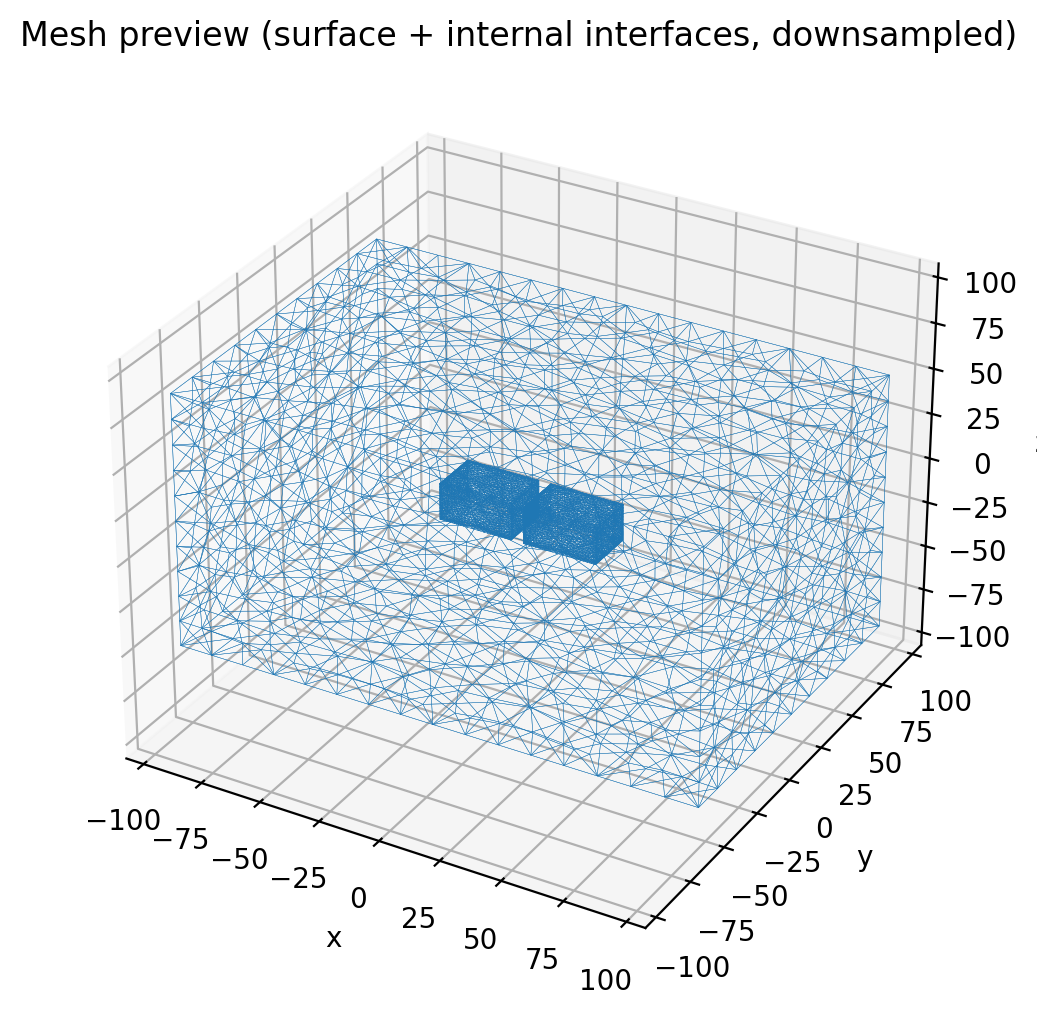

In [ ]:
# Colab cell 6b (optional): quick surface/interface wireframe preview

def preview_msh_surface_wireframe(msh_path: str, max_faces: int) -> None:
    did_init = False
    try:
        if not getattr(gmsh, "isInitialized", lambda: False)():
            gmsh.initialize()
            did_init = True
        gmsh.open(msh_path)

        node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
        node_tags = np.asarray(node_tags, dtype=np.int64)
        node_coords = np.asarray(node_coords, dtype=np.float64).reshape(-1, 3)

        order = np.argsort(node_tags)
        node_tags_sorted = node_tags[order]
        node_coords_sorted = node_coords[order]

        def coords_for_tags(tags: np.ndarray) -> np.ndarray:
            tags = np.asarray(tags, dtype=np.int64)
            idx = np.searchsorted(node_tags_sorted, tags)
            return node_coords_sorted[idx]

        # Derive boundary faces per volume (includes internal interfaces)
        def tet_faces(tets: np.ndarray) -> np.ndarray:
            return np.concatenate(
                [
                    tets[:, [0, 1, 2]],
                    tets[:, [0, 1, 3]],
                    tets[:, [0, 2, 3]],
                    tets[:, [1, 2, 3]],
                ],
                axis=0,
            )

        def boundary_faces_from_tets(tets: np.ndarray) -> np.ndarray:
            f = np.sort(tet_faces(tets), axis=1)
            uniq, counts = np.unique(f, axis=0, return_counts=True)
            return uniq[counts == 1]

        vol_entities = gmsh.model.getEntities(dim=3)
        all_bnd = []
        for _, vtag in vol_entities:
            etypes, _, enodes_list = gmsh.model.mesh.getElements(dim=3, tag=vtag)
            tets_local = []
            for etype, enodes in zip(etypes, enodes_list):
                _, _, _, num_nodes, _, num_primary = gmsh.model.mesh.getElementProperties(etype)
                enodes = np.asarray(enodes, dtype=np.int64).reshape(-1, num_nodes)
                prim = enodes[:, :num_primary]
                if num_primary == 4:
                    tets_local.append(prim)
            if tets_local:
                tets_local = np.vstack(tets_local)
                all_bnd.append(boundary_faces_from_tets(tets_local))

        tri = np.unique(np.vstack(all_bnd), axis=0)
        if tri.shape[0] > max_faces:
            rng = np.random.default_rng(0)
            tri = tri[rng.choice(tri.shape[0], size=max_faces, replace=False)]

        p0 = coords_for_tags(tri[:, 0])
        p1 = coords_for_tags(tri[:, 1])
        p2 = coords_for_tags(tri[:, 2])

        segs = np.concatenate(
            [np.stack([p0, p1], axis=1), np.stack([p1, p2], axis=1), np.stack([p2, p0], axis=1)],
            axis=0,
        )

    finally:
        if did_init:
            try:
                gmsh.finalize()
            except Exception:
                pass

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(Line3DCollection(segs, linewidths=0.15))

    mins = node_coords.min(axis=0)
    maxs = node_coords.max(axis=0)
    center = 0.5 * (mins + maxs)
    span = float((maxs - mins).max())

    ax.set_xlim(center[0] - 0.5 * span, center[0] + 0.5 * span)
    ax.set_ylim(center[1] - 0.5 * span, center[1] + 0.5 * span)
    ax.set_zlim(center[2] - 0.5 * span, center[2] + 0.5 * span)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Mesh preview (surface + internal interfaces, downsampled)")
    plt.show()


preview_msh_surface_wireframe(PARAMS["MSH_PATH"], max_faces=int(PARAMS["PREVIEW_MAX_FACES"]))


In [ ]:
# Colab cell 7: rewrite to MSH v2.2 WITHOUT losing surface elements, then ElmerGrid convert

msh_in = PARAMS["MSH_PATH"]
msh_msh2 = PARAMS["MSH_MSH2_PATH"]
mesh_dir = PARAMS["ELMER_MESH_DIR"]

if not os.path.exists(msh_in):
    raise FileNotFoundError(f"Missing input mesh: {msh_in}")

# --- Rewrite to MSH 2.2 but KEEP all elements (including 2D surface elements) ---
gmsh.initialize()
try:
    gmsh.option.setNumber("General.Terminal", 1)
    gmsh.open(msh_in)

    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)

    # CRITICAL: keep all elements, not only Physical Groups.
    # Without this, 2D surface elements can be dropped in the rewrite step.
    gmsh.option.setNumber("Mesh.SaveAll", 1)

    gmsh.write(msh_msh2)
finally:
    gmsh.finalize()

# --- Sanity check: ensure rewritten mesh has 2D surface elements ---
m2 = meshio.read(msh_msh2)
cell_types = sorted(set(cb.type for cb in m2.cells))
print("MSH2 cell types present:", cell_types)

has_surface_cells = any(ct in ("triangle", "quad") for ct in cell_types)
if not has_surface_cells:
    raise RuntimeError(
        "The rewritten MSH2 file contains no 2D surface elements (triangle/quad). "
        "ElmerGrid cannot generate mesh.boundary without 2D elements. "
        "This indicates Gmsh still wrote only volume (3D) elements. "
        "Next escalation: define a Physical Surface group for the outer air box faces "
        "before meshing, or skip the rewrite step by writing MSH2.2 directly in generate_mesh()."
    )

# --- Convert with ElmerGrid ---
if os.path.isdir(mesh_dir):
    subprocess.run(["rm", "-rf", mesh_dir], check=False)

subprocess.run(
    ["ElmerGrid", "14", "2", msh_msh2, "-autoclean", "-decimals", "12", "-out", mesh_dir],
    check=True
)

print("Converted Elmer mesh dir:", mesh_dir)
for fn in sorted(os.listdir(mesh_dir)):
    fp = os.path.join(mesh_dir, fn)
    print(f"  {fn:20s} {os.path.getsize(fp)} bytes")

boundary_path = os.path.join(mesh_dir, "mesh.boundary")
if not os.path.exists(boundary_path):
    raise RuntimeError("ElmerGrid conversion did not produce mesh.boundary at all.")
if os.path.getsize(boundary_path) == 0:
    raise RuntimeError(
        "ElmerGrid produced mesh.boundary but it is empty. "
        "This still means no boundary elements were created. "
        "Most likely your MSH2 file still lacks explicit 2D surface elements."
    )


MSH2 cell types present: ['line', 'tetra', 'triangle', 'vertex']
Converted Elmer mesh dir: mesh
  entities.sif         124 bytes
  mesh.boundary        397224 bytes
  mesh.elements        1091222 bytes
  mesh.header          56 bytes
  mesh.names           70 bytes
  mesh.nodes           288819 bytes


In [ ]:
# Colab cell 8: parse Elmer mesh + detect bodies + detect external boundary IDs

from collections import defaultdict

mesh_dir = PARAMS["ELMER_MESH_DIR"]

def read_elmer_nodes(mesh_dir: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    mesh.nodes rows: node_id partition x y z
    Returns:
      node_ids: (N,)
      coords: (N,3)
    """
    path = os.path.join(mesh_dir, "mesh.nodes")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {path}")

    node_ids: List[int] = []
    coords: List[List[float]] = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            parts = s.split()
            if len(parts) < 5:
                continue
            node_ids.append(int(parts[0]))
            coords.append([float(parts[2]), float(parts[3]), float(parts[4])])

    if not node_ids:
        raise RuntimeError(f"No nodes parsed from {path}")

    return np.asarray(node_ids, dtype=np.int64), np.asarray(coords, dtype=np.float64)


def read_elmer_elements(mesh_dir: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    mesh.elements rows: elem_id body_id type node1 node2 ...
    Returns:
      body_ids: (Ne,)
      conns: object array (Ne,) each entry is (k,) int node list
    """
    path = os.path.join(mesh_dir, "mesh.elements")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {path}")

    body_ids: List[int] = []
    conns: List[np.ndarray] = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            parts = s.split()
            if len(parts) < 6:
                continue
            body_ids.append(int(parts[1]))
            conns.append(np.asarray([int(p) for p in parts[3:]], dtype=np.int64))

    if not body_ids:
        raise RuntimeError(f"No elements parsed from {path}")

    return np.asarray(body_ids, dtype=np.int64), np.asarray(conns, dtype=object)


def read_elmer_boundary(mesh_dir: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    mesh.boundary rows: belem_id bndry_id p1 p2 type node1 node2 ...
    Returns:
      bndry_ids: (Nb,)
      conns: object array (Nb,) each entry is (k,) int node list
    """
    path = os.path.join(mesh_dir, "mesh.boundary")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {path}")

    bndry_ids: List[int] = []
    conns: List[np.ndarray] = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            parts = s.split()
            if len(parts) < 8:
                continue
            bndry_ids.append(int(parts[1]))
            conns.append(np.asarray([int(p) for p in parts[5:]], dtype=np.int64))

    if not bndry_ids:
        # This is exactly the failure you hit; now it will be reported here.
        raise RuntimeError(
            "Parsed zero boundary elements from mesh.boundary. "
            "This means ElmerGrid created no boundary elements. "
            "Re-check Cell 7: the MSH2 file must contain triangle/quad cells before conversion."
        )

    return np.asarray(bndry_ids, dtype=np.int64), np.asarray(conns, dtype=object)


# --- Read mesh files ---
node_ids, coords = read_elmer_nodes(mesh_dir)
elem_body_ids, elem_conns = read_elmer_elements(mesh_dir)
bndry_ids, bndry_conns = read_elmer_boundary(mesh_dir)

print("Elmer mesh parsed:")
print("  nodes:", node_ids.size)
print("  elements:", elem_body_ids.size)
print("  boundary elements:", bndry_ids.size)

# Node lookup
node_xyz: Dict[int, np.ndarray] = {int(n): coords[i] for i, n in enumerate(node_ids)}

# Global bounding box from nodes
mins = coords.min(axis=0)
maxs = coords.max(axis=0)
span = float((maxs - mins).max())

xmin, ymin, zmin = mins
xmax, ymax, zmax = maxs

# Tolerance for comparing boundary bboxes to global bbox
tol = max(1.0e-6 * span, 1.0e-6)

print("Global bounds (mesh units):")
print("  xmin,xmax =", xmin, xmax)
print("  ymin,ymax =", ymin, ymax)
print("  zmin,zmax =", zmin, zmax)
print("  tol      =", tol)

# --- Detect external boundary IDs (group-wise bbox) ---
nodes_by_bid: Dict[int, set] = defaultdict(set)
for bid, conn in zip(bndry_ids, bndry_conns):
    bid_i = int(bid)
    for n in conn:
        nodes_by_bid[bid_i].add(int(n))

external_bndries: List[int] = []
debug_rows: List[Dict[str, Any]] = []

for bid_i in sorted(nodes_by_bid.keys()):
    nodes = sorted(nodes_by_bid[bid_i])
    pts = np.asarray([node_xyz[n] for n in nodes], dtype=np.float64)
    bmin = pts.min(axis=0)
    bmax = pts.max(axis=0)

    touch_xmin = abs(bmin[0] - xmin) <= tol
    touch_xmax = abs(bmax[0] - xmax) <= tol
    touch_ymin = abs(bmin[1] - ymin) <= tol
    touch_ymax = abs(bmax[1] - ymax) <= tol
    touch_zmin = abs(bmin[2] - zmin) <= tol
    touch_zmax = abs(bmax[2] - zmax) <= tol

    touches = (touch_xmin or touch_xmax or touch_ymin or touch_ymax or touch_zmin or touch_zmax)
    if touches:
        external_bndries.append(bid_i)

    debug_rows.append({
        "boundary_id": bid_i,
        "n_nodes": len(nodes),
        "bbox_xmin": float(bmin[0]),
        "bbox_xmax": float(bmax[0]),
        "bbox_ymin": float(bmin[1]),
        "bbox_ymax": float(bmax[1]),
        "bbox_zmin": float(bmin[2]),
        "bbox_zmax": float(bmax[2]),
        "touch_xmin": bool(touch_xmin),
        "touch_xmax": bool(touch_xmax),
        "touch_ymin": bool(touch_ymin),
        "touch_ymax": bool(touch_ymax),
        "touch_zmin": bool(touch_zmin),
        "touch_zmax": bool(touch_zmax),
    })

external_bndries = sorted(set(external_bndries))

print("Unique boundary IDs present:", sorted(nodes_by_bid.keys()))
print("Detected external boundary IDs:", external_bndries)

try:
    import pandas as pd
    df = pd.DataFrame(debug_rows).sort_values("boundary_id").reset_index(drop=True)
    display(df)
except Exception:
    for row in debug_rows:
        print(row)

if len(external_bndries) < 1:
    raise RuntimeError(
        "External boundary detection returned zero IDs. "
        "This is unusual if the air box is the global bounding box. "
        "Next escalation: define an explicit Physical Surface group for the outer air-box faces in Gmsh "
        "and/or inspect mesh.boundary grouping."
    )

# --- Classify bodies: air vs magnets ---
unique_bodies, counts = np.unique(elem_body_ids, return_counts=True)
order = np.argsort(counts)[::-1]
unique_bodies = unique_bodies[order]
counts = counts[order]

print("Body element counts (descending):")
for b, c in zip(unique_bodies.tolist(), counts.tolist()):
    print("  body", int(b), "elements", int(c))

if unique_bodies.size < 3:
    raise RuntimeError(f"Expected at least 3 bodies, found: {unique_bodies.tolist()}")

air_body = int(unique_bodies[0])
mag_a = int(unique_bodies[1])
mag_b = int(unique_bodies[2])

def body_mean_x(body_id: int) -> float:
    idx = np.where(elem_body_ids == body_id)[0]
    if idx.size == 0:
        return float("nan")
    # Downsample for speed on large meshes
    step = max(1, idx.size // 5000)
    idx = idx[::step]
    xs = []
    for i in idx:
        nodes = elem_conns[i]
        corner = nodes[:4] if nodes.size >= 4 else nodes
        pts = np.asarray([node_xyz[int(n)] for n in corner], dtype=np.float64)
        xs.append(float(pts[:, 0].mean()))
    return float(np.mean(xs))

mx_a = body_mean_x(mag_a)
mx_b = body_mean_x(mag_b)

mag_left_body, mag_right_body = (mag_a, mag_b) if mx_a < mx_b else (mag_b, mag_a)

print("Body classification:")
print("  AIR        =", air_body)
print("  MAG_LEFT   =", mag_left_body, "(mean x:", body_mean_x(mag_left_body), ")")
print("  MAG_RIGHT  =", mag_right_body, "(mean x:", body_mean_x(mag_right_body), ")")


Elmer mesh parsed:
  nodes: 6951
  elements: 34892
  boundary elements: 10956
Global bounds (mesh units):
  xmin,xmax = -107.5 107.5
  ymin,ymax = -70.0 70.0
  zmin,zmax = -70.0 70.0
  tol      = 0.000215
Unique boundary IDs present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Detected external boundary IDs: [13, 14, 15, 16, 17, 18]


,boundary_id,n_nodes,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,bbox_zmin,bbox_zmax,touch_xmin,touch_xmax,touch_ymin,touch_ymax,touch_zmin,touch_zmax
0,1,366,-32.5,-32.5,-10.0,10.0,-10.0,10.0,False,False,False,False,False,False
1,2,382,-2.5,-2.5,-10.0,10.0,-10.0,10.0,False,False,False,False,False,False
2,3,441,-32.5,-2.5,-10.0,-10.0,-10.0,10.0,False,False,False,False,False,False
3,4,454,-32.5,-2.5,10.0,10.0,-10.0,10.0,False,False,False,False,False,False
4,5,436,-32.5,-2.5,-10.0,10.0,-10.0,-10.0,False,False,False,False,False,False
5,6,459,-32.5,-2.5,-10.0,10.0,10.0,10.0,False,False,False,False,False,False
6,7,366,2.5,2.5,-10.0,10.0,-10.0,10.0,False,False,False,False,False,False
7,8,382,32.5,32.5,-10.0,10.0,-10.0,10.0,False,False,False,False,False,False
8,9,441,2.5,32.5,-10.0,-10.0,-10.0,10.0,False,False,False,False,False,False
9,10,454,2.5,32.5,10.0,10.0,-10.0,10.0,False,False,False,False,False,False


Body element counts (descending):
  body 3 elements 20963
  body 2 elements 6967
  body 1 elements 6962
Body classification:
  AIR        = 3
  MAG_LEFT   = 1 (mean x: -17.220024147390365 )
  MAG_RIGHT  = 2 (mean x: 17.774019909649603 )


In [ ]:
# Colab cell 9: write Elmer case.sif

results_dir = PARAMS["RESULTS_DIR"]
os.makedirs(results_dir, exist_ok=True)

if len(external_bndries) < 1:
    raise RuntimeError("No external boundary IDs detected; cannot apply AV=0 outer boundary condition.")

target_bndry_line = " ".join(str(i) for i in external_bndries)

sif_text = f"""\
Header
  CHECK KEYWORDS Warn
  Mesh DB "." "{mesh_dir}"
  Results Directory "{results_dir}"
End

Simulation
  Max Output Level = 5
  Coordinate System = Cartesian
  Coordinate Mapping(3) = 1 2 3
  Simulation Type = Steady state
  Steady State Max Iterations = 1
  Output Intervals(1) = 1
  Coordinate Scaling = {float(PARAMS["COORDINATE_SCALING"]):.16g}
End

Constants
  Permittivity of Vacuum = 8.85418781e-12
  Permeability of Vacuum = {float(PARAMS["MU0"]):.16g}
End

Body 1
  Target Bodies(1) = {mag_left_body}
  Name = "Magnet N"
  Equation = 1
  Material = 2
End

Body 2
  Target Bodies(1) = {mag_right_body}
  Name = "Magnet S"
  Equation = 1
  Material = 3
End

Body 3
  Target Bodies(1) = {air_body}
  Name = "Air"
  Equation = 1
  Material = 1
End

Solver 1
  Equation = MgDyn
  Procedure = "MagnetoDynamics" "WhitneyAVSolver"
  Optimize Bandwidth = True

  Nonlinear System Convergence Tolerance = {float(PARAMS["NONLINEAR_TOL"]):.16g}
  Nonlinear System Max Iterations = 50
  Nonlinear System Newton After Iterations = 3
  Nonlinear System Newton After Tolerance = 1.0e-3
  Nonlinear System Relaxation Factor = 1

  Linear System Solver = Iterative
  Linear System Iterative Method = BiCGStabl
  Linear System Max Iterations = 500
  Linear System Convergence Tolerance = {float(PARAMS["LINEAR_TOL"]):.16g}
  BiCGstabl polynomial degree = 4
  Linear System Preconditioning = none
  Linear System Abort Not Converged = False
  Linear System Residual Output = 10
  Linear System Precondition Recompute = 1
End

Solver 2
  Equation = MgDynPost
  Procedure = "MagnetoDynamics" "MagnetoDynamicsCalcFields"
  Optimize Bandwidth = True

  Calculate Nodal Fields = False
  Calculate Elemental Fields = True
  Calculate Magnetic Field Strength = True
  Average Within Materials = Logical True
End

Solver 3
  Equation = "SaveLine"
  Procedure = "SaveData" "SaveLine"
  Filename = "line_B.dat"
  Polyline Coordinates(2,3) = {float(PARAMS["LINE_X0"]):.16g} {float(PARAMS["LINE_Y"]):.16g} {float(PARAMS["LINE_Z"]):.16g}   {float(PARAMS["LINE_X1"]):.16g} {float(PARAMS["LINE_Y"]):.16g} {float(PARAMS["LINE_Z"]):.16g}
  Polyline Divisions(1) = {int(PARAMS["LINE_DIV"])}
End

Solver 4
  Exec Solver = after timestep
  Equation = "ResultOutput"
  Procedure = "ResultOutputSolve" "ResultOutputSolver"
  Output File Name = field
  Vtu format = True
  Discontinuous Bodies = True
  Save Geometry Ids = True
  Save Linear Elements = True
  Save Bulk Only = True
  Vtu Part Collection = True
End

Equation 1
  Name = "Equation 1"
  Active Solvers(4) = 1 2 3 4
End

Material 1
  Name = "Air (room temperature)"
  Relative Permeability = {float(PARAMS["AIR_MUR"]):.16g}
End

Material 2
  Name = "N"
  Relative Permeability = {float(PARAMS["MAG_MUR"]):.16g}
  Magnetization 1 = {float(PARAMS["MAG_MX_LEFT"]):.16g}
  Magnetization 2 = 0
  Magnetization 3 = 0
End

Material 3
  Name = "S"
  Relative Permeability = {float(PARAMS["MAG_MUR"]):.16g}
  Magnetization 1 = {float(PARAMS["MAG_MX_RIGHT"]):.16g}
  Magnetization 2 = 0
  Magnetization 3 = 0
End

Boundary Condition 1
  Target Boundaries({len(external_bndries)}) = {target_bndry_line}
  Name = "ExternalBC"
  AV {{e}} = Real 0
End
"""

sif_path = "case.sif"
with open(sif_path, "w", encoding="utf-8") as f:
    f.write(textwrap.dedent(sif_text))

print("Wrote:", sif_path)
print("--- case.sif (first 70 lines) ---")
print("\n".join(open(sif_path, "r", encoding="utf-8").read().splitlines()[:70]))


Wrote: case.sif
--- case.sif (first 70 lines) ---
Header
  CHECK KEYWORDS Warn
  Mesh DB "." "mesh"
  Results Directory "results"
End

Simulation
  Max Output Level = 5
  Coordinate System = Cartesian
  Coordinate Mapping(3) = 1 2 3
  Simulation Type = Steady state
  Steady State Max Iterations = 1
  Output Intervals(1) = 1
  Coordinate Scaling = 0.001
End

Constants
  Permittivity of Vacuum = 8.85418781e-12
  Permeability of Vacuum = 1.25663706e-06
End

Body 1
  Target Bodies(1) = 1
  Name = "Magnet N"
  Equation = 1
  Material = 2
End

Body 2
  Target Bodies(1) = 2
  Name = "Magnet S"
  Equation = 1
  Material = 3
End

Body 3
  Target Bodies(1) = 3
  Name = "Air"
  Equation = 1
  Material = 1
End

Solver 1
  Equation = MgDyn
  Procedure = "MagnetoDynamics" "WhitneyAVSolver"
  Optimize Bandwidth = True

  Nonlinear System Convergence Tolerance = 1e-10
  Nonlinear System Max Iterations = 50
  Nonlinear System Newton After Iterations = 3
  Nonlinear System Newton After Tolerance = 1.0e-

In [ ]:
# Colab cell 10: run ElmerSolver

subprocess.run(["ElmerSolver", "case.sif"], check=True)
print("ElmerSolver finished.")
print("Results dir contents:", sorted(os.listdir(results_dir)))


ElmerSolver finished.
Results dir contents: ['field.pvd', 'field_air_t0001.vtu', 'field_magnet n_t0001.vtu', 'field_magnet s_t0001.vtu', 'line_B.dat', 'line_B.dat.names']


Using VTU: results/field_air_t0001.vtu
Selected field: magnetic field strength e
Field location: point
Using cell block index: 0 type: tetra
Interpreting selected field as: H
No body-id field found in VTU; falling back to geometric classification.
Inferred output_scale (multiplies BUILT boxes): 0.001


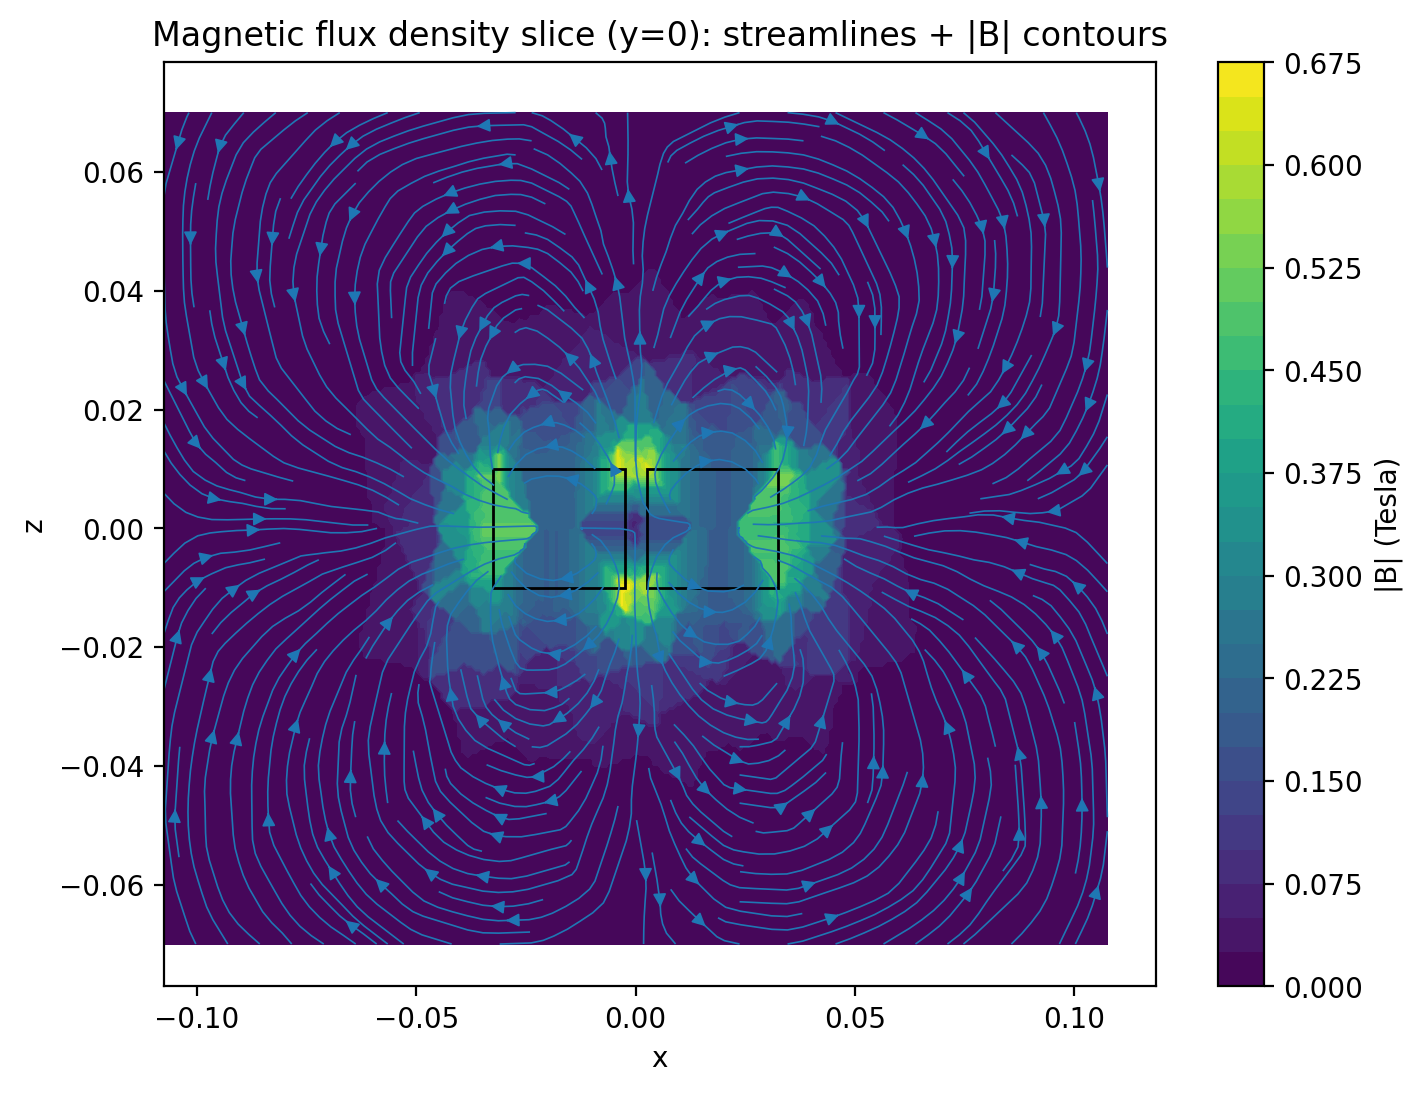

In [ ]:
# Colab cell 11: robust VTU postprocess + magnetic field visualization

import os
import re
import glob
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
import meshio
from scipy.spatial import cKDTree
from matplotlib.patches import Rectangle


def _as_nx3(arr: Any, n: int) -> Optional[np.ndarray]:
    """Try to coerce an array into shape (n, 3)."""
    a = np.asarray(arr)
    if a.size == 0:
        return None

    # Remove trivial singleton dims
    while a.ndim >= 3 and 1 in a.shape:
        a = np.squeeze(a)

    if a.ndim == 2:
        if a.shape == (n, 3):
            return a.astype(np.float64, copy=False)
        if a.shape == (3, n):
            return a.T.astype(np.float64, copy=False)
        if a.size == 3 * n:
            return a.reshape(n, 3).astype(np.float64, copy=False)

    if a.ndim == 1 and a.size == 3 * n:
        return a.reshape(n, 3).astype(np.float64, copy=False)

    return None


def _as_n_scalar(arr: Any, n: int) -> Optional[np.ndarray]:
    """Try to coerce an array into shape (n,) float64."""
    a = np.asarray(arr)
    if a.size == 0:
        return None

    # Remove trivial singleton dims
    while a.ndim >= 2 and 1 in a.shape:
        a = np.squeeze(a)

    if a.ndim == 1 and a.size == n:
        return a.astype(np.float64, copy=False)

    if a.ndim == 2 and a.size == n:
        return a.reshape(n).astype(np.float64, copy=False)

    return None


def _split_component_name(name: str) -> Optional[Tuple[str, int]]:
    """
    Detect component-suffixed names like:
      'Magnetic Field Strength 1'
      'Magnetic Field Strength_2'
      'Magnetic Field Strength(3)'
      'Magnetic Field Strength[1]'
    Returns (base_name, comp_index_zero_based).
    """
    s = name.strip()

    # Space or underscore suffix
    for sep in [" ", "_"]:
        for comp in [1, 2, 3]:
            suf = f"{sep}{comp}"
            if s.endswith(suf):
                base = s[: -len(suf)].rstrip()
                return base, comp - 1

    # Bracket or paren suffix
    for comp in [1, 2, 3]:
        for left, right in [("(", ")"), ("[", "]")]:
            suf = f"{left}{comp}{right}"
            if s.endswith(suf):
                base = s[: -len(suf)].rstrip()
                return base, comp - 1

    return None


def _score_field_name(name: str) -> int:
    """Heuristic scoring to prefer magnetic fields over other vectors."""
    s = name.lower()
    score = 0

    if "magnetic flux density" in s:
        score += 200
    if "flux density" in s:
        score += 160
    if "magnetic field strength" in s:
        score += 180
    if "field strength" in s:
        score += 120
    if "magnetic field" in s:
        score += 140
    if "magnetic" in s:
        score += 60
    if "mgdyn" in s or "magnet" in s:
        score += 10

    # Penalize the vector potential if it sneaks in (still allow as a last resort).
    if re.search(r"\bav\b", s) or "vector potential" in s:
        score -= 40

    return score


def _classify_kind_from_name_and_scale(name: str, vec: np.ndarray) -> str:
    """
    Guess whether a vector is H (A/m) or B (Tesla).
    """
    s = name.lower()
    if "flux density" in s or ("magnetic" in s and "flux" in s):
        return "B"
    if "field strength" in s:
        return "H"

    mag = np.linalg.norm(vec, axis=1)
    finite = mag[np.isfinite(mag)]
    med = float(np.median(finite)) if finite.size else float("nan")

    # Permanent magnet runs: H ~ 1e5 A/m; B ~ 0.1..2 Tesla
    if med > 1.0e3:
        return "H"
    if med < 1.0e2:
        return "B"
    return "Unknown"


def _summarize_available_arrays(mesh: meshio.Mesh) -> None:
    print("VTU summary:")
    print("  point_data keys:", list(mesh.point_data.keys()))
    print("  cell_data keys :", list(mesh.cell_data.keys()))
    print("  cell blocks    :", [(i, cb.type, cb.data.shape) for i, cb in enumerate(mesh.cells)])


def _extract_best_vector_field(
    mesh: meshio.Mesh,
) -> Tuple[str, str, int, np.ndarray, np.ndarray]:
    """
    Returns:
      field_base_name,
      location ('cell' or 'point'),
      tet_block_index,
      vec_cell (Nc,3) at cell centers,
      conn (Nc,k) tetra connectivity for that block.
    """
    tet_block_indices = [i for i, cb in enumerate(mesh.cells) if cb.type in ("tetra", "tetra10")]
    if not tet_block_indices:
        raise RuntimeError("No tetra cell blocks in VTU output.")

    pts = np.asarray(mesh.points, dtype=np.float64)

    # tuple: (score, name, location, block_index, vec_cell, conn)
    candidates: List[Tuple[int, str, str, int, np.ndarray, np.ndarray]] = []

    for bi in tet_block_indices:
        conn = np.asarray(mesh.cells[bi].data, dtype=np.int64)
        n_cells = conn.shape[0]
        corner = conn[:, :4]  # tetra corners

        # ---------- A) Direct vector arrays in CELL data ----------
        for key, arr_list in mesh.cell_data.items():
            if bi >= len(arr_list):
                continue
            vec = _as_nx3(arr_list[bi], n_cells)
            if vec is not None:
                candidates.append((_score_field_name(key), key, "cell", bi, vec, conn))

        # ---------- B) Component scalar arrays in CELL data ----------
        grouped: Dict[str, Dict[int, np.ndarray]] = {}
        for key, arr_list in mesh.cell_data.items():
            if bi >= len(arr_list):
                continue
            split = _split_component_name(key)
            if split is None:
                continue
            base, comp = split
            sc = _as_n_scalar(arr_list[bi], n_cells)
            if sc is None:
                continue
            grouped.setdefault(base, {})[comp] = sc

        for base, comp_map in grouped.items():
            if all(c in comp_map for c in (0, 1, 2)):
                vec = np.stack([comp_map[0], comp_map[1], comp_map[2]], axis=1)
                candidates.append((_score_field_name(base), base, "cell", bi, vec, conn))

        # ---------- C) Direct vector arrays in POINT data ----------
        for key, arr in mesh.point_data.items():
            vecp = _as_nx3(arr, pts.shape[0])
            if vecp is None:
                continue
            vec = vecp[corner].mean(axis=1)
            candidates.append((_score_field_name(key) - 5, key, "point", bi, vec, conn))

        # ---------- D) Component scalar arrays in POINT data ----------
        grouped_p: Dict[str, Dict[int, np.ndarray]] = {}
        for key, arr in mesh.point_data.items():
            split = _split_component_name(key)
            if split is None:
                continue
            base, comp = split
            scp = _as_n_scalar(arr, pts.shape[0])
            if scp is None:
                continue
            grouped_p.setdefault(base, {})[comp] = scp

        for base, comp_map in grouped_p.items():
            if all(c in comp_map for c in (0, 1, 2)):
                vecp = np.stack([comp_map[0], comp_map[1], comp_map[2]], axis=1)
                vec = vecp[corner].mean(axis=1)
                candidates.append((_score_field_name(base) - 5, base, "point", bi, vec, conn))

    if not candidates:
        _summarize_available_arrays(mesh)
        raise RuntimeError(
            "No 3-component vector field could be extracted from the VTU. "
            "This usually means Elmer did not write the field components (e.g., '... 1/2/3'), "
            "or the naming scheme differs from the common Elmer pattern."
        )

    # Pick best by score (descending)
    candidates.sort(key=lambda t: t[0], reverse=True)
    best_score, best_name, best_loc, best_bi, best_vec, best_conn = candidates[0]

    # Light diagnostic if confidence is low
    if best_score < 50:
        print("Warning: low confidence field selection. Top candidates:")
        for sc, nm, loc, bi, _, _ in candidates[:10]:
            print(f"  score={sc:4d}  loc={loc:5s}  block={bi:2d}  name={nm}")

    return best_name, best_loc, best_bi, best_vec, best_conn


def _load_vtu_and_extract_vector(results_dir: str) -> Tuple[str, meshio.Mesh, str, str, int, np.ndarray, np.ndarray]:
    """
    Iterate over VTU candidates (newest first) and return the first one
    that contains tetra cells AND a usable vector field.
    """
    candidates = glob.glob(os.path.join(results_dir, "*.vtu"))
    if not candidates:
        raise RuntimeError(
            f"No .vtu files found in {results_dir}. Found: {sorted(os.listdir(results_dir))}"
        )

    candidates = sorted(candidates, key=lambda p: os.path.getmtime(p), reverse=True)

    last_err: Optional[Exception] = None
    for p in candidates:
        try:
            m = meshio.read(p)
            if not any(cb.type in ("tetra", "tetra10") for cb in m.cells):
                continue
            field_base, field_loc, bi, V_cell, conn = _extract_best_vector_field(m)
            return p, m, field_base, field_loc, bi, V_cell, conn
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(
        "Scanned all VTU files but could not find one with a usable 3D vector field. "
        f"Last error: {last_err}"
    )


def infer_output_scale(pts_xyz: np.ndarray, built: Dict[str, Any], coord_scaling: float) -> float:
    """
    Try scale=1 and scale=coord_scaling; choose which best matches the air-box span.
    """
    air_box = np.asarray(built["air_box"], dtype=np.float64)  # in mesh units (mm)
    built_span = np.array(
        [air_box[3] - air_box[0], air_box[4] - air_box[1], air_box[5] - air_box[2]],
        dtype=np.float64,
    )
    actual_span = pts_xyz.max(axis=0) - pts_xyz.min(axis=0)

    s1 = 1.0
    s2 = float(coord_scaling)
    err1 = float(np.linalg.norm(actual_span - built_span * s1))
    err2 = float(np.linalg.norm(actual_span - built_span * s2))
    return s1 if err1 < err2 else s2


def in_box(c: np.ndarray, box: np.ndarray) -> np.ndarray:
    xmin_, ymin_, zmin_, xmax_, ymax_, zmax_ = [float(v) for v in box]
    x, y, z = c[:, 0], c[:, 1], c[:, 2]
    return (x >= xmin_) & (x <= xmax_) & (y >= ymin_) & (y <= ymax_) & (z >= zmin_) & (z <= zmax_)


# ------------------- Execute: load VTU and extract a magnetic field -------------------

results_dir = PARAMS["RESULTS_DIR"]

vtu_path, m, field_base, field_loc, bi, V_cell, conn = _load_vtu_and_extract_vector(results_dir)
print("Using VTU:", vtu_path)
print("Selected field:", field_base)
print("Field location:", field_loc)
print("Using cell block index:", bi, "type:", m.cells[bi].type)

pts = np.asarray(m.points, dtype=np.float64)
corner = np.asarray(conn[:, :4], dtype=np.int64)
centers = pts[corner].mean(axis=1)

# Decide whether V_cell is B or H
field_kind = _classify_kind_from_name_and_scale(field_base, V_cell)
print("Interpreting selected field as:", field_kind)

# Body IDs (if present in VTU cell data)
def pick_body_id_field(mesh: meshio.Mesh, bi: int, expected_ids: Sequence[int]) -> Optional[Tuple[str, np.ndarray]]:
    expected = set(int(x) for x in expected_ids)
    n_cells = mesh.cells[bi].data.shape[0]

    for k, arr_list in mesh.cell_data.items():
        if bi >= len(arr_list):
            continue
        arr = np.asarray(arr_list[bi])
        arr1 = arr.reshape(-1)
        if arr1.size != n_cells:
            continue

        arr_int = np.asarray(np.rint(arr1), dtype=np.int64)
        uniq = set(np.unique(arr_int).tolist())
        if expected.issubset(uniq):
            return k, arr_int
    return None


body_ids_info = pick_body_id_field(m, bi, expected_ids=[air_body, mag_left_body, mag_right_body])
if body_ids_info is not None:
    body_key, body_ids = body_ids_info
    print("Using body-id field from VTU cell data:", body_key)
else:
    print("No body-id field found in VTU; falling back to geometric classification.")
    body_ids = None

# Infer output coordinate scale once (works even if body_ids are present)
output_scale = infer_output_scale(pts, BUILT, float(PARAMS["COORDINATE_SCALING"]))
print("Inferred output_scale (multiplies BUILT boxes):", output_scale)

# Masks for magnets/air
if body_ids is not None:
    in_left = (body_ids == mag_left_body)
    in_right = (body_ids == mag_right_body)
    air_mask = (body_ids == air_body)
else:
    mag1 = np.asarray(BUILT["mag1_box"], dtype=np.float64) * output_scale
    mag2 = np.asarray(BUILT["mag2_box"], dtype=np.float64) * output_scale
    in_left = in_box(centers, mag1)
    in_right = in_box(centers, mag2)
    air_mask = ~(in_left | in_right)

mu0 = float(PARAMS["MU0"])
mur_air = float(PARAMS["AIR_MUR"])
mur_mag = float(PARAMS["MAG_MUR"])
MxL = float(PARAMS["MAG_MX_LEFT"])
MxR = float(PARAMS["MAG_MX_RIGHT"])

# Compute B_cell
if field_kind == "B":
    B_cell = V_cell
else:
    # Treat as H (including Unknown)
    mur = np.full((V_cell.shape[0],), mur_air, dtype=np.float64)
    M = np.zeros_like(V_cell, dtype=np.float64)

    mur[in_left] = mur_mag
    mur[in_right] = mur_mag
    M[in_left, 0] = MxL
    M[in_right, 0] = MxR

    B_cell = mu0 * (mur[:, None] * V_cell + M)

# Focus on air region for “around the magnets”
cent_air = centers[air_mask]
B_air = B_cell[air_mask]

if cent_air.shape[0] < 10:
    raise RuntimeError(
        f"Air selection produced too few cells ({cent_air.shape[0]}). "
        "If you do not have body IDs in the VTU, this can happen if output_scale inference failed."
    )

# Slice plane y = SLICE_Y (PARAMS is in mesh units, so scale into output coordinates)
y_slice = float(PARAMS["SLICE_Y"]) * output_scale
nx = int(PARAMS["GRID_NX"])
nz = int(PARAMS["GRID_NZ"])

xmin, ymin, zmin = pts.min(axis=0)
xmax, ymax, zmax = pts.max(axis=0)

xg = np.linspace(xmin, xmax, nx)
zg = np.linspace(zmin, zmax, nz)
X, Z = np.meshgrid(xg, zg, indexing="xy")
Y = np.full_like(X, y_slice)

query_pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

tree = cKDTree(cent_air)
_, idx = tree.query(query_pts, k=1)

Bq = B_air[idx].reshape(nz, nx, 3)
Bx = Bq[:, :, 0]
Bz = Bq[:, :, 2]
Bmag = np.sqrt((Bq ** 2).sum(axis=2))

fig, ax = plt.subplots()
ax.set_title(f"Magnetic flux density slice (y={y_slice:g}): streamlines + |B| contours")

ax.streamplot(xg, zg, Bx, Bz, density=2.0, linewidth=0.6)
cf = ax.contourf(xg, zg, Bmag, levels=30)

ax.set_xlabel("x")
ax.set_ylabel("z")
plt.colorbar(cf, ax=ax, label="|B| (Tesla)")

# Overlay magnet rectangles (scaled into output coordinates)
mag1 = np.asarray(BUILT["mag1_box"], dtype=np.float64) * output_scale
mag2 = np.asarray(BUILT["mag2_box"], dtype=np.float64) * output_scale
ax.add_patch(Rectangle((mag1[0], mag1[2]), mag1[3] - mag1[0], mag1[5] - mag1[2], fill=False))
ax.add_patch(Rectangle((mag2[0], mag2[2]), mag2[3] - mag2[0], mag2[5] - mag2[2], fill=False))

plt.show()

Using VTU: results/field_air_t0001.vtu
Selected field: magnetic field strength e
Field location: point
Using cell block index: 0 type: tetra
Interpreting selected field as: H
No body-id field found in VTU; falling back to geometric classification.
Inferred output_scale (multiplies BUILT boxes): 0.001


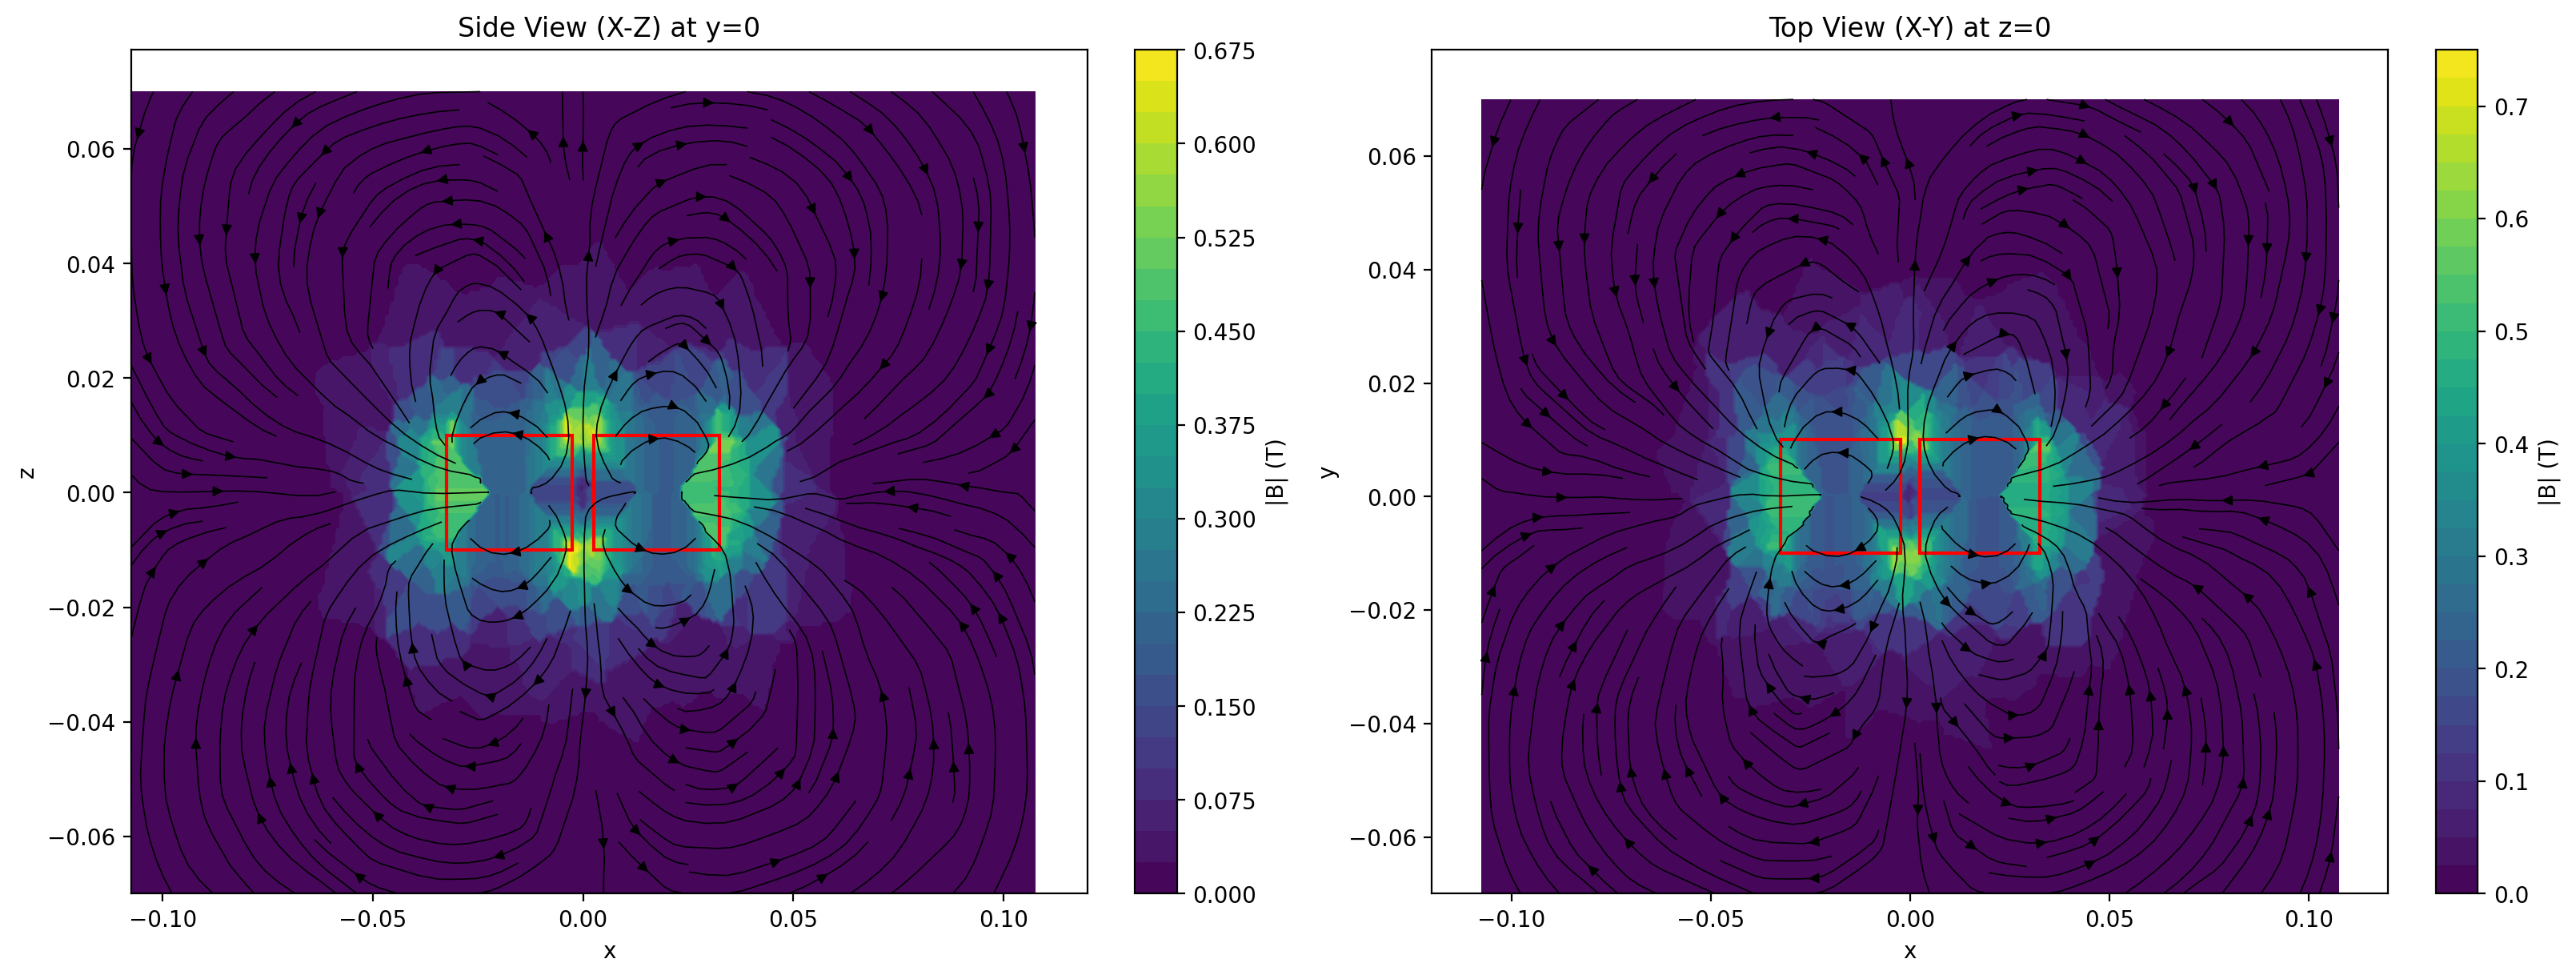

In [ ]:
# Colab cell 11b: robust VTU postprocess + magnetic field visualization

import os
import re
import glob
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
import meshio
from scipy.spatial import cKDTree
from matplotlib.patches import Rectangle


def _as_nx3(arr: Any, n: int) -> Optional[np.ndarray]:
    """Try to coerce an array into shape (n, 3)."""
    a = np.asarray(arr)
    if a.size == 0:
        return None

    # Remove trivial singleton dims
    while a.ndim >= 3 and 1 in a.shape:
        a = np.squeeze(a)

    if a.ndim == 2:
        if a.shape == (n, 3):
            return a.astype(np.float64, copy=False)
        if a.shape == (3, n):
            return a.T.astype(np.float64, copy=False)
        if a.size == 3 * n:
            return a.reshape(n, 3).astype(np.float64, copy=False)

    if a.ndim == 1 and a.size == 3 * n:
        return a.reshape(n, 3).astype(np.float64, copy=False)

    return None


def _as_n_scalar(arr: Any, n: int) -> Optional[np.ndarray]:
    """Try to coerce an array into shape (n,) float64."""
    a = np.asarray(arr)
    if a.size == 0:
        return None

    # Remove trivial singleton dims
    while a.ndim >= 2 and 1 in a.shape:
        a = np.squeeze(a)

    if a.ndim == 1 and a.size == n:
        return a.astype(np.float64, copy=False)

    if a.ndim == 2 and a.size == n:
        return a.reshape(n).astype(np.float64, copy=False)

    return None


def _split_component_name(name: str) -> Optional[Tuple[str, int]]:
    """
    Detect component-suffixed names like:
      'Magnetic Field Strength 1'
      'Magnetic Field Strength_2'
      'Magnetic Field Strength(3)'
      'Magnetic Field Strength[1]'
    Returns (base_name, comp_index_zero_based).
    """
    s = name.strip()

    # Space or underscore suffix
    for sep in [" ", "_"]:
        for comp in [1, 2, 3]:
            suf = f"{sep}{comp}"
            if s.endswith(suf):
                base = s[: -len(suf)].rstrip()
                return base, comp - 1

    # Bracket or paren suffix
    for comp in [1, 2, 3]:
        for left, right in [("(", ")"), ("[", "]")]:
            suf = f"{left}{comp}{right}"
            if s.endswith(suf):
                base = s[: -len(suf)].rstrip()
                return base, comp - 1

    return None


def _score_field_name(name: str) -> int:
    """Heuristic scoring to prefer magnetic fields over other vectors."""
    s = name.lower()
    score = 0

    if "magnetic flux density" in s:
        score += 200
    if "flux density" in s:
        score += 160
    if "magnetic field strength" in s:
        score += 180
    if "field strength" in s:
        score += 120
    if "magnetic field" in s:
        score += 140
    if "magnetic" in s:
        score += 60
    if "mgdyn" in s or "magnet" in s:
        score += 10

    # Penalize the vector potential if it sneaks in (still allow as a last resort).
    if re.search(r"\bav\b", s) or "vector potential" in s:
        score -= 40

    return score


def _classify_kind_from_name_and_scale(name: str, vec: np.ndarray) -> str:
    """
    Guess whether a vector is H (A/m) or B (Tesla).
    """
    s = name.lower()
    if "flux density" in s or ("magnetic" in s and "flux" in s):
        return "B"
    if "field strength" in s:
        return "H"

    mag = np.linalg.norm(vec, axis=1)
    finite = mag[np.isfinite(mag)]
    med = float(np.median(finite)) if finite.size else float("nan")

    # Permanent magnet runs: H ~ 1e5 A/m; B ~ 0.1..2 Tesla
    if med > 1.0e3:
        return "H"
    if med < 1.0e2:
        return "B"
    return "Unknown"


def _summarize_available_arrays(mesh: meshio.Mesh) -> None:
    print("VTU summary:")
    print("  point_data keys:", list(mesh.point_data.keys()))
    print("  cell_data keys :", list(mesh.cell_data.keys()))
    print("  cell blocks     :", [(i, cb.type, cb.data.shape) for i, cb in enumerate(mesh.cells)])


def _extract_best_vector_field(
    mesh: meshio.Mesh,
) -> Tuple[str, str, int, np.ndarray, np.ndarray]:
    """
    Returns:
      field_base_name,
      location ('cell' or 'point'),
      tet_block_index,
      vec_cell (Nc,3) at cell centers,
      conn (Nc,k) tetra connectivity for that block.
    """
    tet_block_indices = [i for i, cb in enumerate(mesh.cells) if cb.type in ("tetra", "tetra10")]
    if not tet_block_indices:
        raise RuntimeError("No tetra cell blocks in VTU output.")

    pts = np.asarray(mesh.points, dtype=np.float64)

    # tuple: (score, name, location, block_index, vec_cell, conn)
    candidates: List[Tuple[int, str, str, int, np.ndarray, np.ndarray]] = []

    for bi in tet_block_indices:
        conn = np.asarray(mesh.cells[bi].data, dtype=np.int64)
        n_cells = conn.shape[0]
        corner = conn[:, :4]  # tetra corners

        # ---------- A) Direct vector arrays in CELL data ----------
        for key, arr_list in mesh.cell_data.items():
            if bi >= len(arr_list):
                continue
            vec = _as_nx3(arr_list[bi], n_cells)
            if vec is not None:
                candidates.append((_score_field_name(key), key, "cell", bi, vec, conn))

        # ---------- B) Component scalar arrays in CELL data ----------
        grouped: Dict[str, Dict[int, np.ndarray]] = {}
        for key, arr_list in mesh.cell_data.items():
            if bi >= len(arr_list):
                continue
            split = _split_component_name(key)
            if split is None:
                continue
            base, comp = split
            sc = _as_n_scalar(arr_list[bi], n_cells)
            if sc is None:
                continue
            grouped.setdefault(base, {})[comp] = sc

        for base, comp_map in grouped.items():
            if all(c in comp_map for c in (0, 1, 2)):
                vec = np.stack([comp_map[0], comp_map[1], comp_map[2]], axis=1)
                candidates.append((_score_field_name(base), base, "cell", bi, vec, conn))

        # ---------- C) Direct vector arrays in POINT data ----------
        for key, arr in mesh.point_data.items():
            vecp = _as_nx3(arr, pts.shape[0])
            if vecp is None:
                continue
            vec = vecp[corner].mean(axis=1)
            candidates.append((_score_field_name(key) - 5, key, "point", bi, vec, conn))

        # ---------- D) Component scalar arrays in POINT data ----------
        grouped_p: Dict[str, Dict[int, np.ndarray]] = {}
        for key, arr in mesh.point_data.items():
            split = _split_component_name(key)
            if split is None:
                continue
            base, comp = split
            scp = _as_n_scalar(arr, pts.shape[0])
            if scp is None:
                continue
            grouped_p.setdefault(base, {})[comp] = scp

        for base, comp_map in grouped_p.items():
            if all(c in comp_map for c in (0, 1, 2)):
                vecp = np.stack([comp_map[0], comp_map[1], comp_map[2]], axis=1)
                vec = vecp[corner].mean(axis=1)
                candidates.append((_score_field_name(base) - 5, base, "point", bi, vec, conn))

    if not candidates:
        _summarize_available_arrays(mesh)
        raise RuntimeError(
            "No 3-component vector field could be extracted from the VTU. "
            "This usually means Elmer did not write the field components (e.g., '... 1/2/3'), "
            "or the naming scheme differs from the common Elmer pattern."
        )

    # Pick best by score (descending)
    candidates.sort(key=lambda t: t[0], reverse=True)
    best_score, best_name, best_loc, best_bi, best_vec, best_conn = candidates[0]

    # Light diagnostic if confidence is low
    if best_score < 50:
        print("Warning: low confidence field selection. Top candidates:")
        for sc, nm, loc, bi, _, _ in candidates[:10]:
            print(f"  score={sc:4d}  loc={loc:5s}  block={bi:2d}  name={nm}")

    return best_name, best_loc, best_bi, best_vec, best_conn


def _load_vtu_and_extract_vector(results_dir: str) -> Tuple[str, meshio.Mesh, str, str, int, np.ndarray, np.ndarray]:
    """
    Iterate over VTU candidates (newest first) and return the first one
    that contains tetra cells AND a usable vector field.
    """
    candidates = glob.glob(os.path.join(results_dir, "*.vtu"))
    if not candidates:
        raise RuntimeError(
            f"No .vtu files found in {results_dir}. Found: {sorted(os.listdir(results_dir))}"
        )

    candidates = sorted(candidates, key=lambda p: os.path.getmtime(p), reverse=True)

    last_err: Optional[Exception] = None
    for p in candidates:
        try:
            m = meshio.read(p)
            if not any(cb.type in ("tetra", "tetra10") for cb in m.cells):
                continue
            field_base, field_loc, bi, V_cell, conn = _extract_best_vector_field(m)
            return p, m, field_base, field_loc, bi, V_cell, conn
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(
        "Scanned all VTU files but could not find one with a usable 3D vector field. "
        f"Last error: {last_err}"
    )


def infer_output_scale(pts_xyz: np.ndarray, built: Dict[str, Any], coord_scaling: float) -> float:
    """
    Try scale=1 and scale=coord_scaling; choose which best matches the air-box span.
    """
    air_box = np.asarray(built["air_box"], dtype=np.float64)  # in mesh units (mm)
    built_span = np.array(
        [air_box[3] - air_box[0], air_box[4] - air_box[1], air_box[5] - air_box[2]],
        dtype=np.float64,
    )
    actual_span = pts_xyz.max(axis=0) - pts_xyz.min(axis=0)

    s1 = 1.0
    s2 = float(coord_scaling)
    err1 = float(np.linalg.norm(actual_span - built_span * s1))
    err2 = float(np.linalg.norm(actual_span - built_span * s2))
    return s1 if err1 < err2 else s2


def in_box(c: np.ndarray, box: np.ndarray) -> np.ndarray:
    xmin_, ymin_, zmin_, xmax_, ymax_, zmax_ = [float(v) for v in box]
    x, y, z = c[:, 0], c[:, 1], c[:, 2]
    return (x >= xmin_) & (x <= xmax_) & (y >= ymin_) & (y <= ymax_) & (z >= zmin_) & (z <= zmax_)


# ------------------- Execute: load VTU and extract a magnetic field -------------------

results_dir = PARAMS["RESULTS_DIR"]

vtu_path, m, field_base, field_loc, bi, V_cell, conn = _load_vtu_and_extract_vector(results_dir)
print("Using VTU:", vtu_path)
print("Selected field:", field_base)
print("Field location:", field_loc)
print("Using cell block index:", bi, "type:", m.cells[bi].type)

pts = np.asarray(m.points, dtype=np.float64)
corner = np.asarray(conn[:, :4], dtype=np.int64)
centers = pts[corner].mean(axis=1)

# Decide whether V_cell is B or H
field_kind = _classify_kind_from_name_and_scale(field_base, V_cell)
print("Interpreting selected field as:", field_kind)

# Body IDs (if present in VTU cell data)
def pick_body_id_field(mesh: meshio.Mesh, bi: int, expected_ids: Sequence[int]) -> Optional[Tuple[str, np.ndarray]]:
    expected = set(int(x) for x in expected_ids)
    n_cells = mesh.cells[bi].data.shape[0]

    for k, arr_list in mesh.cell_data.items():
        if bi >= len(arr_list):
            continue
        arr = np.asarray(arr_list[bi])
        arr1 = arr.reshape(-1)
        if arr1.size != n_cells:
            continue

        arr_int = np.asarray(np.rint(arr1), dtype=np.int64)
        uniq = set(np.unique(arr_int).tolist())
        if expected.issubset(uniq):
            return k, arr_int
    return None


body_ids_info = pick_body_id_field(m, bi, expected_ids=[air_body, mag_left_body, mag_right_body])
if body_ids_info is not None:
    body_key, body_ids = body_ids_info
    print("Using body-id field from VTU cell data:", body_key)
else:
    print("No body-id field found in VTU; falling back to geometric classification.")
    body_ids = None

# Infer output coordinate scale once (works even if body_ids are present)
output_scale = infer_output_scale(pts, BUILT, float(PARAMS["COORDINATE_SCALING"]))
print("Inferred output_scale (multiplies BUILT boxes):", output_scale)

# Masks for magnets/air
if body_ids is not None:
    in_left = (body_ids == mag_left_body)
    in_right = (body_ids == mag_right_body)
    air_mask = (body_ids == air_body)
else:
    mag1_check = np.asarray(BUILT["mag1_box"], dtype=np.float64) * output_scale
    mag2_check = np.asarray(BUILT["mag2_box"], dtype=np.float64) * output_scale
    in_left = in_box(centers, mag1_check)
    in_right = in_box(centers, mag2_check)
    air_mask = ~(in_left | in_right)

mu0 = float(PARAMS["MU0"])
mur_air = float(PARAMS["AIR_MUR"])
mur_mag = float(PARAMS["MAG_MUR"])
MxL = float(PARAMS["MAG_MX_LEFT"])
MxR = float(PARAMS["MAG_MX_RIGHT"])

# Compute B_cell
if field_kind == "B":
    B_cell = V_cell
else:
    # Treat as H (including Unknown)
    mur = np.full((V_cell.shape[0],), mur_air, dtype=np.float64)
    M = np.zeros_like(V_cell, dtype=np.float64)

    mur[in_left] = mur_mag
    mur[in_right] = mur_mag
    M[in_left, 0] = MxL
    M[in_right, 0] = MxR

    B_cell = mu0 * (mur[:, None] * V_cell + M)

# Focus on air region for “around the magnets”
cent_air = centers[air_mask]
B_air = B_cell[air_mask]

if cent_air.shape[0] < 10:
    raise RuntimeError(
        f"Air selection produced too few cells ({cent_air.shape[0]}). "
        "If you do not have body IDs in the VTU, this can happen if output_scale inference failed."
    )

# ----------------- PLOTTING: Dual View (Side and Top) -----------------

xmin, ymin, zmin = pts.min(axis=0)
xmax, ymax, zmax = pts.max(axis=0)

nx = int(PARAMS["GRID_NX"])
nz = int(PARAMS["GRID_NZ"])

# Pre-calculate magnet boxes in output scale for overlays
mag1 = np.asarray(BUILT["mag1_box"], dtype=np.float64) * output_scale
mag2 = np.asarray(BUILT["mag2_box"], dtype=np.float64) * output_scale

# Build KDTree for interpolation
tree = cKDTree(cent_air)

# Create two subplots: Side View and Top View
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# --- 1. SIDE VIEW (X-Z plane at constant Y) ---
# Slice plane y = SLICE_Y
y_slice = float(PARAMS["SLICE_Y"]) * output_scale

xg = np.linspace(xmin, xmax, nx)
zg = np.linspace(zmin, zmax, nz)
X, Z = np.meshgrid(xg, zg, indexing="xy")
Y = np.full_like(X, y_slice)

query_pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
_, idx = tree.query(query_pts, k=1)

Bq = B_air[idx].reshape(nz, nx, 3)
Bx = Bq[:, :, 0]
Bz = Bq[:, :, 2]
Bmag = np.sqrt((Bq ** 2).sum(axis=2))

ax_side = axes[0]
ax_side.set_title(f"Side View (X-Z) at y={y_slice:.3g}")
st = ax_side.streamplot(xg, zg, Bx, Bz, density=1.5, linewidth=0.6, color='k')
cf = ax_side.contourf(xg, zg, Bmag, levels=30, cmap='viridis')
ax_side.set_xlabel("x")
ax_side.set_ylabel("z")
fig.colorbar(cf, ax=ax_side, label="|B| (T)")

# Overlay magnets (Side view: x vs z)
ax_side.add_patch(Rectangle((mag1[0], mag1[2]), mag1[3] - mag1[0], mag1[5] - mag1[2],
                            fill=False, edgecolor='red', linewidth=1.5))
ax_side.add_patch(Rectangle((mag2[0], mag2[2]), mag2[3] - mag2[0], mag2[5] - mag2[2],
                            fill=False, edgecolor='red', linewidth=1.5))


# --- 2. TOP VIEW (X-Y plane at constant Z) ---
# Calculate z_slice from the center of the magnets
z_center_mag1 = (mag1[2] + mag1[5]) / 2.0
z_center_mag2 = (mag2[2] + mag2[5]) / 2.0
z_slice = (z_center_mag1 + z_center_mag2) / 2.0

ny = nx  # Use same resolution for Y as X

xg = np.linspace(xmin, xmax, nx)
yg = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xg, yg, indexing="xy")
Z = np.full_like(X, z_slice)

query_pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
_, idx = tree.query(query_pts, k=1)

Bq = B_air[idx].reshape(ny, nx, 3)
Bx = Bq[:, :, 0]
By = Bq[:, :, 1]
Bmag = np.sqrt((Bq ** 2).sum(axis=2))

ax_top = axes[1]
ax_top.set_title(f"Top View (X-Y) at z={z_slice:.3g}")
st = ax_top.streamplot(xg, yg, Bx, By, density=1.5, linewidth=0.6, color='k')
cf = ax_top.contourf(xg, yg, Bmag, levels=30, cmap='viridis')
ax_top.set_xlabel("x")
ax_top.set_ylabel("y")
fig.colorbar(cf, ax=ax_top, label="|B| (T)")

# Overlay magnets (Top view: x vs y)
# mag box indices: 0=xmin, 1=ymin, 3=xmax, 4=ymax
ax_top.add_patch(Rectangle((mag1[0], mag1[1]), mag1[3] - mag1[0], mag1[4] - mag1[1],
                           fill=False, edgecolor='red', linewidth=1.5))
ax_top.add_patch(Rectangle((mag2[0], mag2[1]), mag2[3] - mag2[0], mag2[4] - mag2[1],
                           fill=False, edgecolor='red', linewidth=1.5))

plt.show()

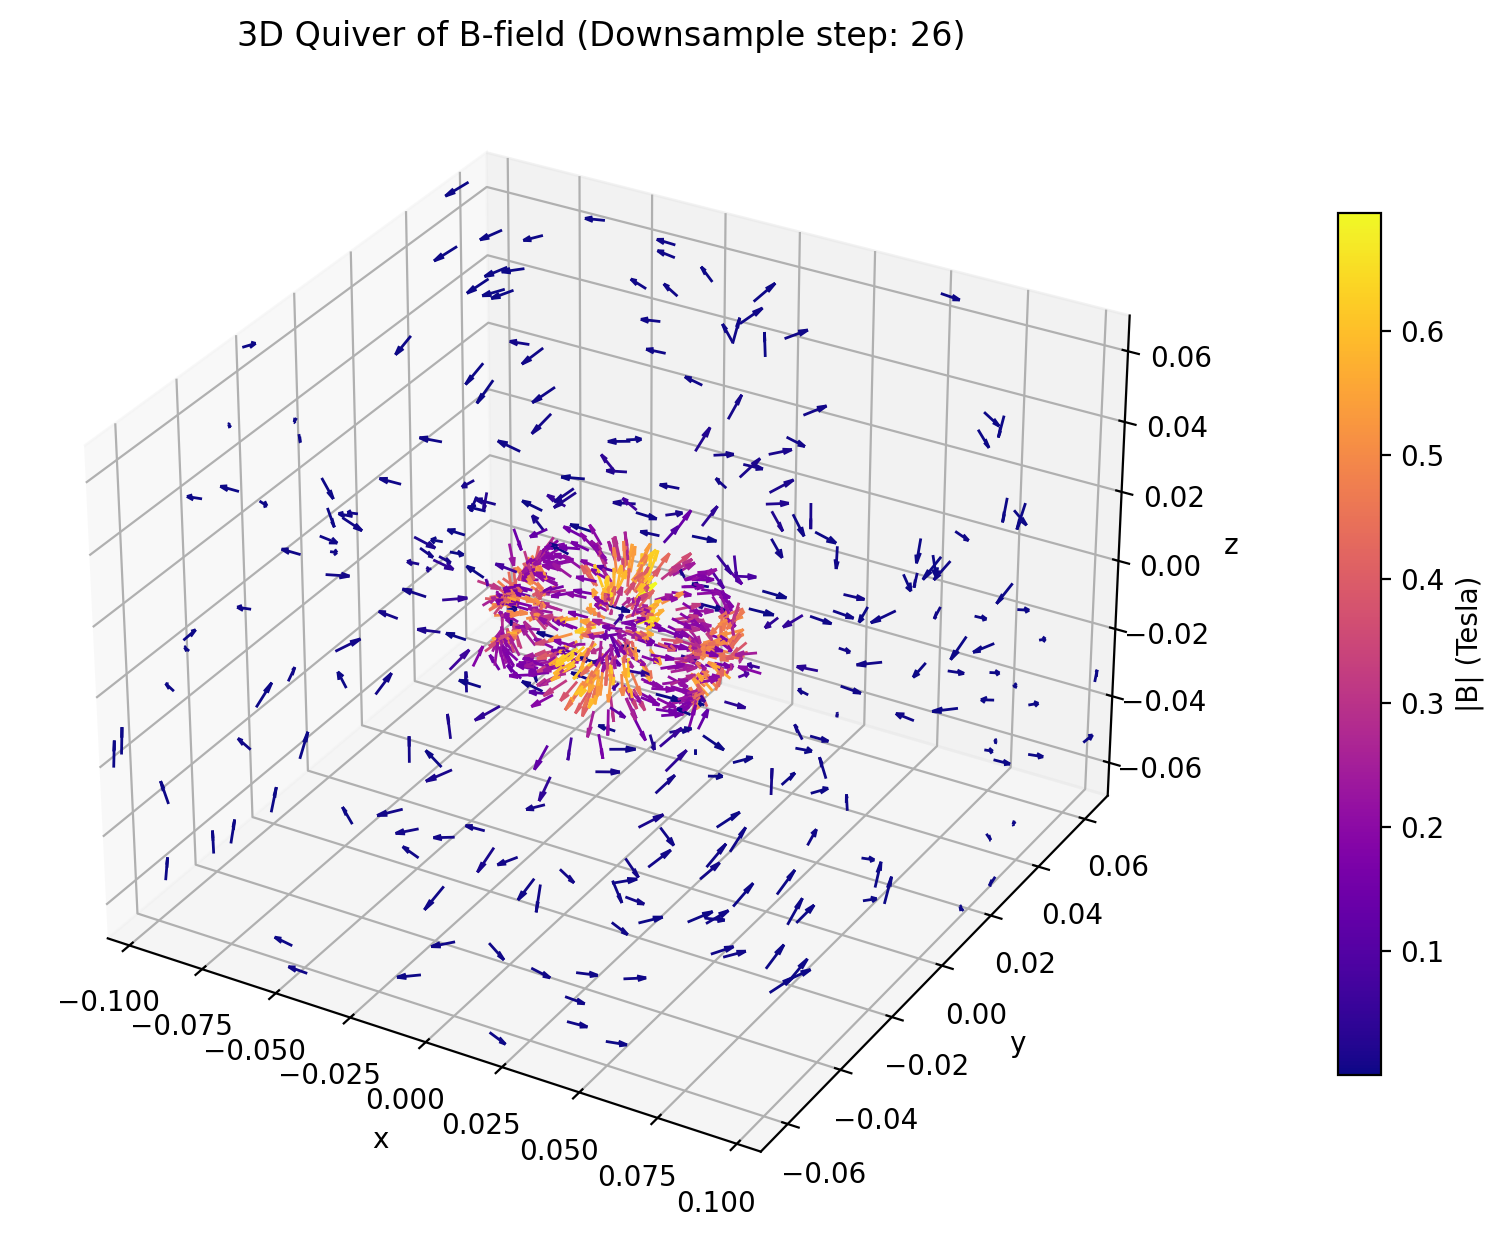

In [ ]:
# Colab cell 12: 3D quiver with color gradient and density control

from matplotlib import cm
from matplotlib.colors import Normalize

# 1. Fix Density: Target a maximum number of arrows to prevent clutter
target_arrows = 800
n_total = cent_air.shape[0]
# Use the larger of the user param or our calculated stride
ds_param = int(PARAMS.get("VEC_DOWNSAMPLE", 1))
ds_calc = max(1, n_total // target_arrows)
ds = max(ds_param, ds_calc)

cent_ds = cent_air[::ds]
B_ds = B_air[::ds]

# 2. Prepare Colors: Map magnetic magnitude to a colormap
B_mag = np.linalg.norm(B_ds, axis=1)
# Avoid division by zero if all B are 0 (unlikely)
if B_mag.max() > 0:
    # Normalize B_mag to 0-1 range for the colormap
    norm = Normalize(vmin=B_mag.min(), vmax=B_mag.max())
    # Get RGBA colors from a scientific colormap (e.g., 'plasma', 'viridis', 'turbo')
    cmap = plt.cm.plasma
    colors = cmap(norm(B_mag))
else:
    colors = 'k'
    norm = Normalize(vmin=0, vmax=1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.set_title(f"3D Quiver of B-field (Downsample step: {ds})")

# 3. Plot Quiver with Colors
# length defines the length of the arrows in axes coordinate space
q = ax.quiver(
    cent_ds[:, 0], cent_ds[:, 1], cent_ds[:, 2],
    B_ds[:, 0], B_ds[:, 1], B_ds[:, 2],
    colors=colors,
    length=0.03 * max(xmax-xmin, ymax-ymin, zmax-zmin), # Scale length relative to domain
    normalize=True, # Arrows same size to show direction clearly; color shows magnitude
    arrow_length_ratio=0.4,
    linewidth=1
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

# 4. Add Colorbar
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(B_mag)
cbar = plt.colorbar(mappable, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("|B| (Tesla)")

plt.show()

In [ ]:
# Colab cell 13: Export 3D data to ParaView (.vtu)

import sys
import subprocess
import numpy as np

# Ensure meshio is installed
try:
    import meshio
except ImportError:
    print("Installing meshio...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "meshio"])
    import meshio

from google.colab import files


def export_quiver_to_paraview(
    points: np.ndarray,
    vectors: np.ndarray,
    filename: str = "magnetic_field_quiver.vtu"
) -> None:
    """
    Export a 3D vector field to a VTU file compatible with ParaView.

    This function creates a point-cloud mesh where every point is a 'vertex'
    cell. It attaches the vector field as point data.

    Args:
        points: (N, 3) float array of spatial coordinates (x, y, z).
        vectors: (N, 3) float array of vector components (Bx, By, Bz).
        filename: The name of the output file (default: 'magnetic_field_quiver.vtu').

    Returns:
        None
    """
    # Ensure inputs are valid numpy arrays
    pts = np.asarray(points, dtype=np.float64)
    vecs = np.asarray(vectors, dtype=np.float64)

    n_points = pts.shape[0]
    print(f"Preparing to export {n_points} points to {filename}...")

    # Define cells: Each point is treated as a single vertex
    # Shape must be (N, 1) for vertex cells
    cells = [("vertex", np.arange(n_points, dtype=np.int64).reshape(n_points, 1))]

    # Create the mesh object
    # We store the magnetic field 'B' as Point Data
    mesh = meshio.Mesh(
        pts,
        cells,
        point_data={"B_field": vecs}
    )

    # Write to disk
    mesh.write(filename)
    print(f"Successfully wrote {filename}.")

    # Trigger download in Colab
    try:
        files.download(filename)
    except ImportError:
        print("Download skipped: 'google.colab' module not found (local run).")


# Execute export using the full air-region dataset from Cell 11
# We use the full resolution (cent_air), not the downsampled version,
# because ParaView handles large datasets efficiently.
if 'cent_air' in locals() and 'B_air' in locals():
    export_quiver_to_paraview(cent_air, B_air)
else:
    print("Error: Data 'cent_air' or 'B_air' not found. Please run Cell 11 first.")

Preparing to export 20963 points to magnetic_field_quiver.vtu...
Successfully wrote magnetic_field_quiver.vtu.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>